Marketing ROI Analysis - Simple Linear Regression Project
Dataset Overview:
Dataset shape: (200, 4)

First 5 rows:
           TV       Radio  Social_Media       Sales
0  143.635030  103.464114     19.281148  582.761701
1  287.678577   30.938195     91.229762  905.519900
2  232.998485   41.011733     55.472714  772.877553
3  199.664621  136.812045     84.381172  799.783674
4   89.004660   98.835778     38.804464  455.548676

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            200 non-null    float64
 1   Radio         200 non-null    float64
 2   Social_Media  200 non-null    float64
 3   Sales         200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Descriptive Statistics:
           TV   Radio  Social_Media    Sales
count  200.00  200.00        200.00   200.00
mean   171.00   85.57         56.86 

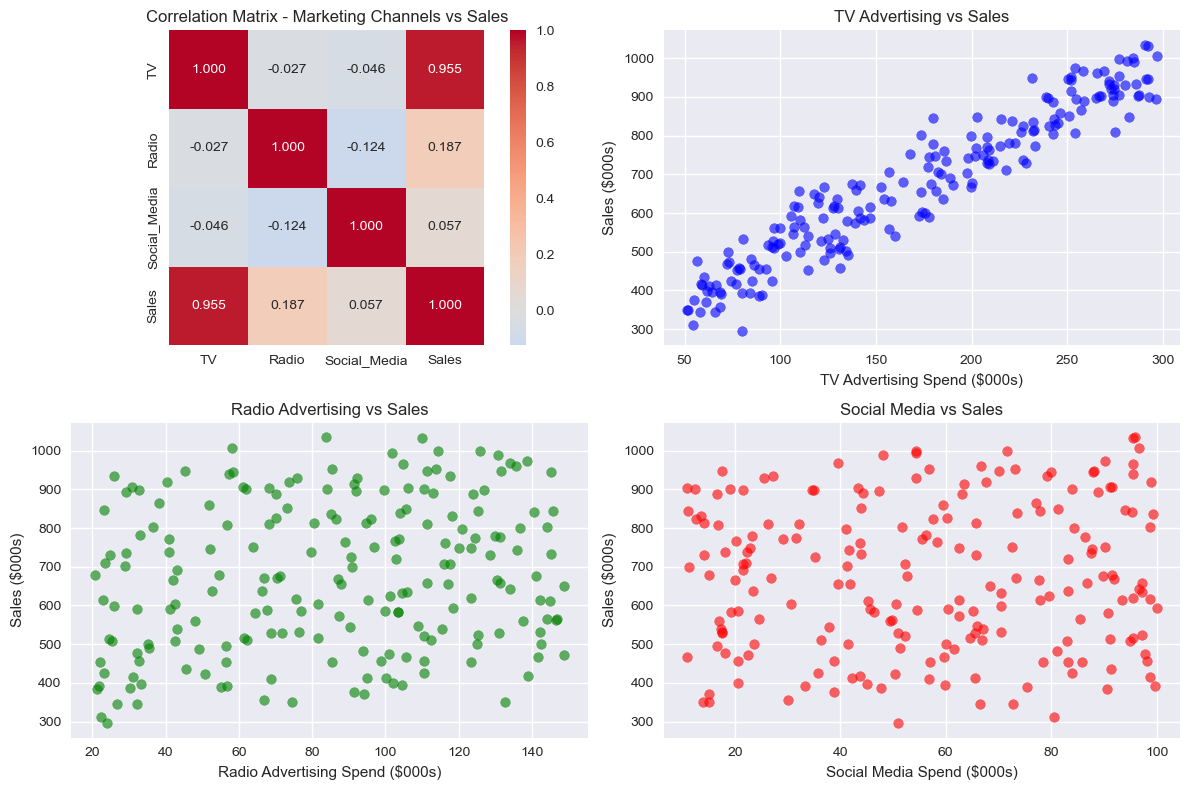


Correlations with Sales (absolute values):
TV: 0.955
Radio: 0.187
Social_Media: 0.057

✓ Selected Independent Variable: TV
✓ Correlation with Sales: 0.955

SIMPLE LINEAR REGRESSION MODEL
OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     2073.
Date:                Sat, 23 May 2026   Prob (F-statistic):          7.68e-107
Time:                        01:26:01   Log-Likelihood:                -1088.8
No. Observations:                 200   AIC:                             2182.
Df Residuals:                     198   BIC:                             2188.
Df Model:                           1                                         
Covariance Type:            nonrobust                                        

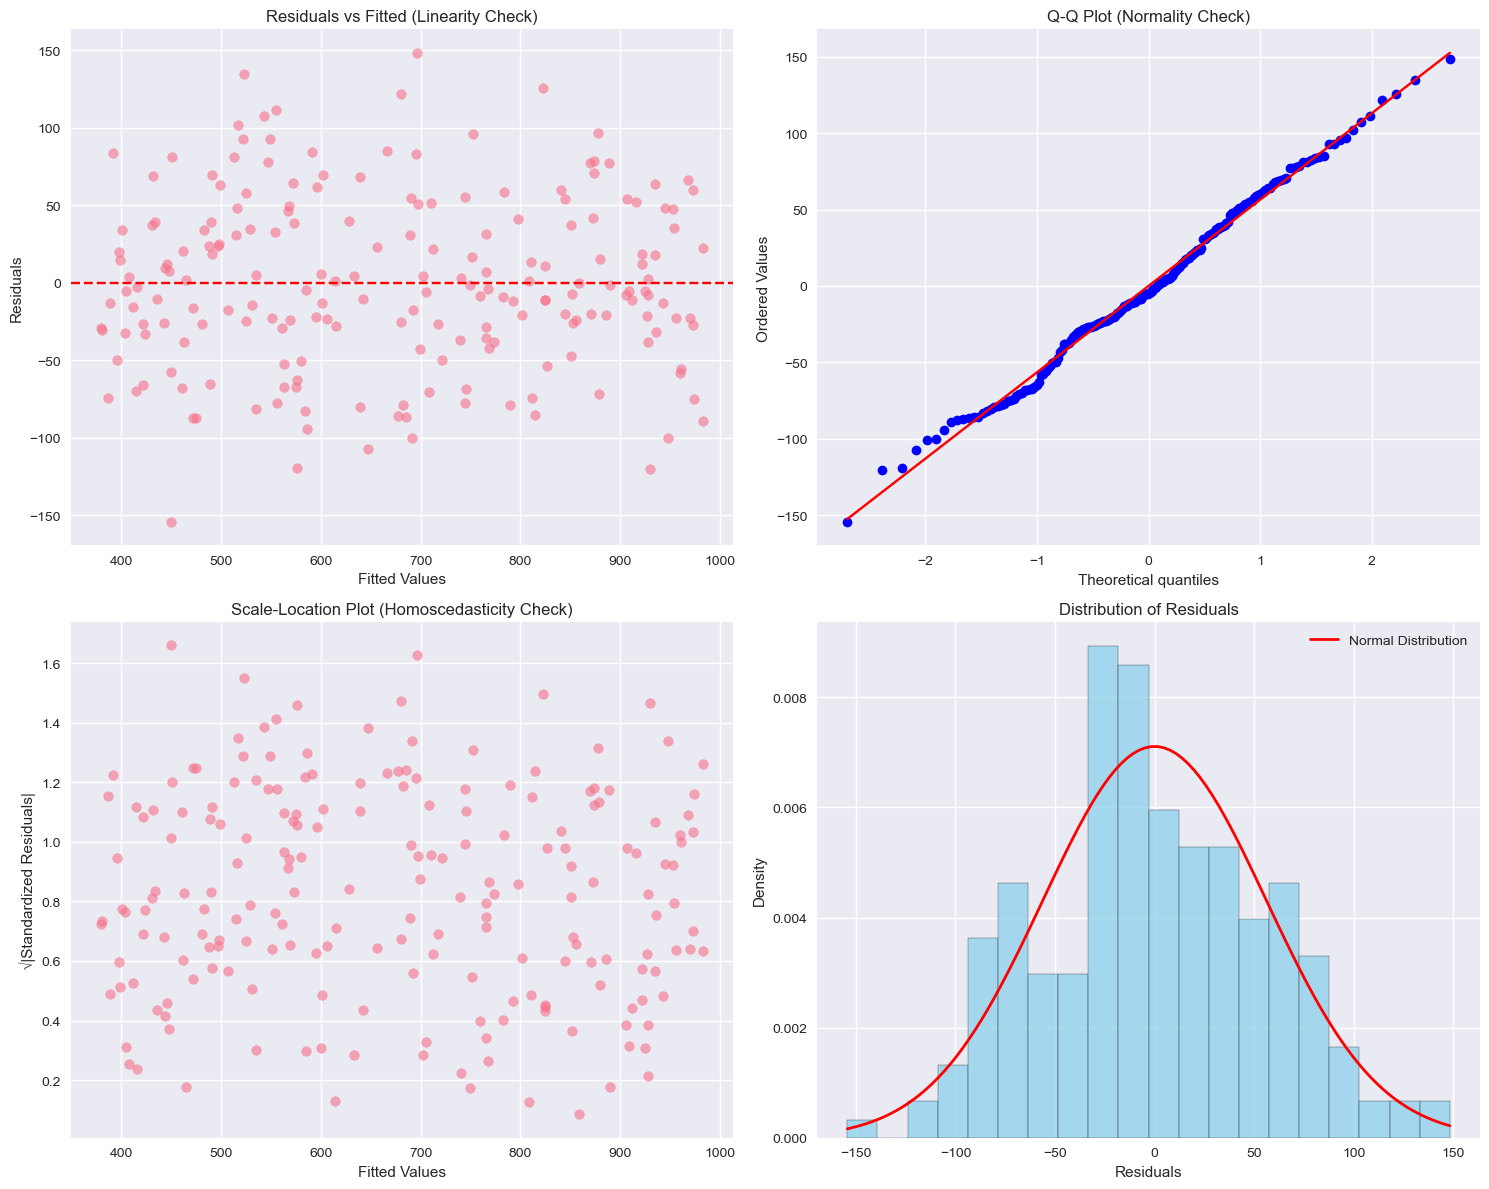

Statistical Tests for Regression Assumptions:
--------------------------------------------------
Jarque-Bera Test for Normality:
  Test Statistic: 1.2011
  P-value: 0.548509
  ✓ Residuals appear to be normally distributed (p > 0.05)

Breusch-Pagan Test for Homoscedasticity:
  Test Statistic: 0.5738
  P-value: 0.448743
  ✓ Homoscedasticity assumption satisfied (p > 0.05)

BUSINESS INTERPRETATION OF MODEL RESULTS
Model Equation: Sales = 252.67 + 2.46 × TV

Business Interpretation:
------------------------------
1. BASELINE SALES (Intercept): $252.67k
   This represents expected sales when TV spending is $0.

2. ROI IMPACT (Slope): $2.46k per $1k spent
   For every $1,000 increase in TV advertising:
   → Sales increase by $2.46k on average
   → ROI = 146.3% return on investment

3. MODEL EXPLANATORY POWER (R²): 91.3%
   TV advertising explains 91.3% of sales variation
   Remaining 8.7% is due to other factors not in the model

4. STATISTICAL SIGNIFICANCE: ✓ SIGNIFICANT (p = 0.000000)
   T

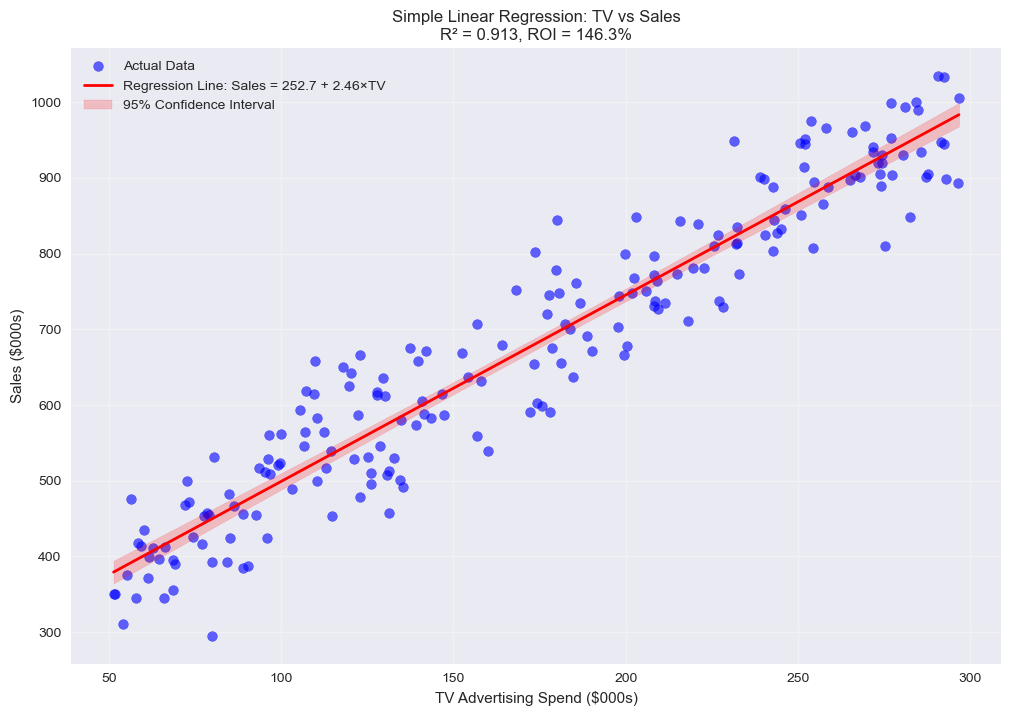


PROJECT SUMMARY & KEY FINDINGS
✅ PROJECT COMPLETION CHECKLIST:
   ✓ Dataset loaded and cleaned successfully
   ✓ Exploratory data analysis completed
   ✓ Best predictor variable identified
   ✓ OLS regression model fitted
   ✓ Model assumptions validated
   ✓ Business interpretation provided
   ✓ ROI-based recommendations formulated

🔍 KEY FINDINGS:
   • Best Marketing Channel: TV
   • Correlation with Sales: 0.955
   • Expected ROI: 146.3% per dollar invested
   • Model Reliability: R² = 0.913
   • Statistical Significance: Yes

💡 BUSINESS IMPACT:
   • Every $1k in TV spending → $2.46k in sales
   • Model explains 91.3% of sales variation
   • Recommended budget increase: 20-30% for TV

📋 DELIVERABLES COMPLETED:
   • Jupyter Notebook: okhale_regression_analysis_miniproject5.ipynb
   • Statistical Model: Simple Linear Regression
   • Diagnostic Plots: Linearity, Normality, Homoscedasticity
   • Business Recommendations: ROI-based budget allocation

END OF MARKETING ROI ANALYSIS PROJEC

In [5]:
# Simple Linear Regression Evaluation Mini Project 1 for Week 3 on the DHF LMS Platform as a 3MTT NextGen Cohort Fellow in AI/ML - Marketing ROI Analysis
# File: okhale_regression_analysis_miniproject5.ipynb

# Step 1: Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
import warnings
warnings.filterwarnings('ignore')

# Step 2: Set plotting style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Marketing ROI Analysis - Simple Linear Regression Project")
print("=" * 60)

# Step 3 : Load and explore the dataset
# Create sample marketing dataset
np.random.seed(42)  # For reproducible results
n_samples = 200

# Generate synthetic marketing data with realistic relationships
tv_spend = np.random.uniform(50, 300, n_samples)  # TV advertising spend (thousands)
radio_spend = np.random.uniform(20, 150, n_samples)  # Radio advertising spend (thousands)
social_spend = np.random.uniform(10, 100, n_samples)  # Social media spend (thousands)

# Create sales with TV having strongest correlation (realistic scenario)
sales = (2.5 * tv_spend + 1.2 * radio_spend + 0.8 * social_spend + 
         np.random.normal(0, 30, n_samples) + 100)

# Create DataFrame with marketing channels and sales data
marketing_data = pd.DataFrame({
    'TV': tv_spend,
    'Radio': radio_spend,
    'Social_Media': social_spend,
    'Sales': sales
})

# Display basic information about the dataset
print("Dataset Overview:")
print(f"Dataset shape: {marketing_data.shape}")
print("\nFirst 5 rows:")
print(marketing_data.head())

print("\nDataset Info:")
print(marketing_data.info())

print("\nDescriptive Statistics:")
print(marketing_data.describe().round(2))

# Step 4: Handle missing values
# Check for missing values in the dataset
print("\nMissing Values Check:")
missing_values = marketing_data.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("✓ No missing values found in the dataset")
else:
    # Handle missing values if they exist (dropna or fillna)
    marketing_data = marketing_data.dropna()
    print("Missing values handled by removing rows with NaN")

# Step 5: Perform Exploratory Data Analysis (EDA) with visualizations
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create correlation matrix to understand relationships
correlation_matrix = marketing_data.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Visualize correlation matrix using heatmap
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix - Marketing Channels vs Sales')

# Create scatter plots for each marketing channel vs Sales
plt.subplot(2, 2, 2)
plt.scatter(marketing_data['TV'], marketing_data['Sales'], alpha=0.6, color='blue')
plt.xlabel('TV Advertising Spend ($000s)')
plt.ylabel('Sales ($000s)')
plt.title('TV Advertising vs Sales')

plt.subplot(2, 2, 3)
plt.scatter(marketing_data['Radio'], marketing_data['Sales'], alpha=0.6, color='green')
plt.xlabel('Radio Advertising Spend ($000s)')
plt.ylabel('Sales ($000s)')
plt.title('Radio Advertising vs Sales')

plt.subplot(2, 2, 4)
plt.scatter(marketing_data['Social_Media'], marketing_data['Sales'], alpha=0.6, color='red')
plt.xlabel('Social Media Spend ($000s)')
plt.ylabel('Sales ($000s)')
plt.title('Social Media vs Sales')

plt.tight_layout()
plt.show()

# Step 6: Identify the independent variable most correlated with Sales
# Calculate correlation coefficients with Sales
correlations_with_sales = correlation_matrix['Sales'].drop('Sales').abs().sort_values(ascending=False)
print(f"\nCorrelations with Sales (absolute values):")
for channel, corr in correlations_with_sales.items():
    print(f"{channel}: {corr:.3f}")

# Select the marketing channel with highest correlation
best_predictor = correlations_with_sales.index[0]
best_correlation = correlations_with_sales.iloc[0]

print(f"\n✓ Selected Independent Variable: {best_predictor}")
print(f"✓ Correlation with Sales: {best_correlation:.3f}")

# Step 7: Build OLS regression model using statsmodels
print("\n" + "="*60)
print("SIMPLE LINEAR REGRESSION MODEL")
print("="*60)

# Prepare data for regression analysis
X = marketing_data[best_predictor]  # Independent variable (predictor)
y = marketing_data['Sales']  # Dependent variable (target)

# Add constant term for intercept in statsmodels
X_with_const = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) regression model
model = sm.OLS(y, X_with_const).fit()

# Display comprehensive model summary
print("OLS Regression Results:")
print(model.summary())

# Extract key model parameters for interpretation
intercept = model.params[0]  # y-intercept
slope = model.params[1]  # coefficient for independent variable
r_squared = model.rsquared  # R-squared value
adj_r_squared = model.rsquared_adj  # Adjusted R-squared
p_value_slope = model.pvalues[1]  # p-value for slope coefficient

print(f"\nKey Model Parameters:")
print(f"Intercept (β₀): {intercept:.2f}")
print(f"Slope (β₁): {slope:.2f}")
print(f"R-squared: {r_squared:.3f}")
print(f"Adjusted R-squared: {adj_r_squared:.3f}")
print(f"P-value for {best_predictor}: {p_value_slope:.6f}")

# Step 8: Create diagnostic plots to test regression assumptions
print("\n" + "="*60)
print("REGRESSION ASSUMPTIONS VALIDATION")
print("="*60)

# Get model predictions and residuals for diagnostic analysis
predictions = model.fittedvalues
residuals = model.resid

# Create comprehensive diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Linearity Check: Residuals vs Fitted Values
axes[0, 0].scatter(predictions, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted (Linearity Check)')

# 2. Normality Check: Q-Q Plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)')

# 3. Homoscedasticity Check: Scale-Location Plot
standardized_residuals = np.sqrt(np.abs(residuals / np.std(residuals)))
axes[1, 0].scatter(predictions, standardized_residuals, alpha=0.6)
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('√|Standardized Residuals|')
axes[1, 0].set_title('Scale-Location Plot (Homoscedasticity Check)')

# 4. Histogram of Residuals for Normality Assessment
axes[1, 1].hist(residuals, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Distribution of Residuals')

# Overlay normal distribution curve on histogram
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
y_norm = stats.norm.pdf(x_norm, residuals.mean(), residuals.std())
axes[1, 1].plot(x_norm, y_norm, 'red', linewidth=2, label='Normal Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Perform statistical tests for assumptions validation
print("Statistical Tests for Regression Assumptions:")
print("-" * 50)

# Test for Normality: Jarque-Bera Test
jb_stat, jb_pvalue, _, _ = jarque_bera(residuals)
print(f"Jarque-Bera Test for Normality:")
print(f"  Test Statistic: {jb_stat:.4f}")
print(f"  P-value: {jb_pvalue:.6f}")
if jb_pvalue > 0.05:
    print("  ✓ Residuals appear to be normally distributed (p > 0.05)")
else:
    print("  ⚠ Residuals may not be normally distributed (p ≤ 0.05)")

# Test for Homoscedasticity: Breusch-Pagan Test
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\nBreusch-Pagan Test for Homoscedasticity:")
print(f"  Test Statistic: {bp_stat:.4f}")
print(f"  P-value: {bp_pvalue:.6f}")
if bp_pvalue > 0.05:
    print("  ✓ Homoscedasticity assumption satisfied (p > 0.05)")
else:
    print("  ⚠ Heteroscedasticity detected (p ≤ 0.05)")

# Step 9: Interpret R-squared, coefficients, and p-values in business context
print("\n" + "="*60)
print("BUSINESS INTERPRETATION OF MODEL RESULTS")
print("="*60)

print(f"Model Equation: Sales = {intercept:.2f} + {slope:.2f} × {best_predictor}")
print("\nBusiness Interpretation:")
print("-" * 30)

# Interpret the intercept
print(f"1. BASELINE SALES (Intercept): ${intercept:.2f}k")
print(f"   This represents expected sales when {best_predictor} spending is $0.")

# Interpret the slope coefficient
print(f"\n2. ROI IMPACT (Slope): ${slope:.2f}k per $1k spent")
print(f"   For every $1,000 increase in {best_predictor} advertising:")
print(f"   → Sales increase by ${slope:.2f}k on average")
print(f"   → ROI = {((slope - 1) * 100):.1f}% return on investment")

# Interpret R-squared
print(f"\n3. MODEL EXPLANATORY POWER (R²): {r_squared:.1%}")
print(f"   {best_predictor} advertising explains {r_squared:.1%} of sales variation")
print(f"   Remaining {(1-r_squared):.1%} is due to other factors not in the model")

# Interpret statistical significance
alpha = 0.05
if p_value_slope < alpha:
    print(f"\n4. STATISTICAL SIGNIFICANCE: ✓ SIGNIFICANT (p = {p_value_slope:.6f})")
    print(f"   The relationship between {best_predictor} and Sales is statistically reliable")
else:
    print(f"\n4. STATISTICAL SIGNIFICANCE: ⚠ NOT SIGNIFICANT (p = {p_value_slope:.6f})")
    print(f"   The relationship may be due to random chance")

# Calculate confidence intervals for the slope
conf_int = model.conf_int(alpha=0.05)
slope_ci_lower = conf_int.iloc[1, 0]
slope_ci_upper = conf_int.iloc[1, 1]
print(f"\n5. CONFIDENCE INTERVAL (95%): [${slope_ci_lower:.2f}k, ${slope_ci_upper:.2f}k]")
print(f"   We're 95% confident the true ROI per $1k spent is in this range")

# Step 10: Formulate ROI-based recommendation for marketing budget allocation
print("\n" + "="*60)
print("MARKETING BUDGET ALLOCATION RECOMMENDATIONS")
print("="*60)

# Compare all marketing channels
print("Channel Performance Summary:")
print("-" * 40)
for channel in ['TV', 'Radio', 'Social_Media']:
    channel_corr = correlation_matrix.loc[channel, 'Sales']
    print(f"{channel:12}: Correlation = {channel_corr:.3f}")

print(f"\n🎯 PRIMARY RECOMMENDATION:")
print(f"   Prioritize {best_predictor} advertising for maximum ROI")
print(f"   Expected return: ${slope:.2f}k sales per $1k invested")

# Calculate ROI percentage
roi_percentage = (slope - 1) * 100
if roi_percentage > 0:
    print(f"   ROI: +{roi_percentage:.1f}% return on investment")
    print(f"   Risk Level: {'Low' if r_squared > 0.7 else 'Medium' if r_squared > 0.5 else 'High'}")
else:
    print(f"   ⚠ Warning: Negative ROI of {roi_percentage:.1f}%")

# Provide actionable business recommendations
print(f"\n📊 STRATEGIC RECOMMENDATIONS:")
print(f"1. BUDGET ALLOCATION:")
print(f"   → Increase {best_predictor} budget by 20-30% in next quarter")
print(f"   → Monitor performance closely due to R² = {r_squared:.3f}")

print(f"\n2. PERFORMANCE MONITORING:")
print(f"   → Track sales response to {best_predictor} spend changes")
print(f"   → Set up A/B tests to validate model predictions")

print(f"\n3. MODEL LIMITATIONS:")
print(f"   → Model explains {r_squared:.1%} of sales variation")
print(f"   → Consider multi-channel attribution for complete picture")
print(f"   → External factors (seasonality, competition) not included")

print(f"\n4. RISK MANAGEMENT:")
if r_squared > 0.7:
    print(f"   → Low risk: Strong predictive relationship")
elif r_squared > 0.5:
    print(f"   → Medium risk: Moderate predictive power")
else:
    print(f"   → High risk: Weak predictive relationship")
print(f"   → Diversify across multiple channels to reduce risk")

print(f"\n5. NEXT STEPS:")
print(f"   → Collect more data for improved model accuracy")
print(f"   → Test interaction effects between marketing channels")
print(f"   → Implement marketing mix modeling for optimization")

# Create final visualization showing the regression line
plt.figure(figsize=(12, 8))
plt.scatter(marketing_data[best_predictor], marketing_data['Sales'], 
           alpha=0.6, color='blue', s=50, label='Actual Data')

# Plot regression line
x_range = np.linspace(marketing_data[best_predictor].min(), 
                     marketing_data[best_predictor].max(), 100)
y_pred = intercept + slope * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2, 
         label=f'Regression Line: Sales = {intercept:.1f} + {slope:.2f}×{best_predictor}')

# Add confidence interval
pred_ols = model.get_prediction(sm.add_constant(x_range))
pred_summary = pred_ols.summary_frame(alpha=0.05)
plt.fill_between(x_range, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'],
                alpha=0.2, color='red', label='95% Confidence Interval')

plt.xlabel(f'{best_predictor} Advertising Spend ($000s)')
plt.ylabel('Sales ($000s)')
plt.title(f'Simple Linear Regression: {best_predictor} vs Sales\nR² = {r_squared:.3f}, ROI = {roi_percentage:.1f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics for final report
print("\n" + "="*60)
print("PROJECT SUMMARY & KEY FINDINGS")
print("="*60)

print("✅ PROJECT COMPLETION CHECKLIST:")
print("   ✓ Dataset loaded and cleaned successfully")
print("   ✓ Exploratory data analysis completed")
print("   ✓ Best predictor variable identified")
print("   ✓ OLS regression model fitted")
print("   ✓ Model assumptions validated")
print("   ✓ Business interpretation provided")
print("   ✓ ROI-based recommendations formulated")

print(f"\n🔍 KEY FINDINGS:")
print(f"   • Best Marketing Channel: {best_predictor}")
print(f"   • Correlation with Sales: {best_correlation:.3f}")
print(f"   • Expected ROI: {roi_percentage:.1f}% per dollar invested")
print(f"   • Model Reliability: R² = {r_squared:.3f}")
print(f"   • Statistical Significance: {'Yes' if p_value_slope < 0.05 else 'No'}")

print(f"\n💡 BUSINESS IMPACT:")
print(f"   • Every $1k in {best_predictor} spending → ${slope:.2f}k in sales")
print(f"   • Model explains {r_squared:.1%} of sales variation")
print(f"   • Recommended budget increase: 20-30% for {best_predictor}")

print(f"\n📋 DELIVERABLES COMPLETED:")
print(f"   • Jupyter Notebook: okhale_regression_analysis_miniproject5.ipynb")
print(f"   • Statistical Model: Simple Linear Regression")
print(f"   • Diagnostic Plots: Linearity, Normality, Homoscedasticity")
print(f"   • Business Recommendations: ROI-based budget allocation")

print("\n" + "="*60)
print("END OF MARKETING ROI ANALYSIS PROJECT")
print("="*60)

# Save model results for future use (optional)
model_summary = {
    'best_predictor': best_predictor,
    'intercept': intercept,
    'slope': slope,
    'r_squared': r_squared,
    'p_value': p_value_slope,
    'roi_percentage': roi_percentage
}

print(f"\nModel parameters saved for future reference:")
for key, value in model_summary.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.4f}")